# Post-hoc inference on Lexicographic checkpoints

Inference-only comparison on frozen checkpoints. **No model is retrained.**

Every inference rule is one cell of a **readout x transform** grid, and the same four cells are evaluated for every model:

|  | `node_score` | `subspace_norm` |
|---|---|---|
| **no transform** | rank each node by its own coordinate | rank it by the L2 norm over its ancestors+self+descendants subspace |
| **HCC projection** | `hcc_node_score` | `hcc_subspace_norm` |

Each checkpoint's own inference is one of these cells — `node_score` for H-CAST, HT-CapsNet and HRN, `subspace_norm` for Hier-COS, and the HCC-prefixed cell for a checkpoint trained with HCC — so the comparison asks one question of every model: **does aggregating over the taxonomy subspace, or projecting onto the hierarchy constraint, beat what the model already does?**

`subspace_norm` aggregates each model's **own per-level probabilities**, not raw logits, because an L2 norm is not invariant to a monotone map: `‖f(z)‖` is not a monotone function of `‖z‖`. Softmax for H-CAST and HT-CapsNet, sigmoid/sigmoid/softmax for HRN, identity for Hier-COS, whose training already drives non-target coordinate magnitudes to ~0. `node_score` is unaffected, since every one of those activations is monotone and cannot change a per-level argmax. Set `SUBSPACE_SCORE_SPACE = 'coordinate'` to reproduce raw-logit results.

**This notebook covers one training mechanism: lexicographic** — lexicographic gradient projection in coarse-first order (`train.lexicographic.enabled`). The mechanism acts on the *gradient*, so nothing about it is visible at inference time; the question here is whether the representation it leaves behind reacts to a post-hoc readout differently from the baseline one.

The key quantity here is the within-checkpoint **gain against that checkpoint's native cell**: the two rows come from one set of weights, so the only thing that differs is the inference rule. Positive always means the listed cell is better, including for the lower-is-better AHD and TICE. Every completed seed is evaluated separately; its YAML stays in that seed's run directory, and tables and plots report mean ± sample standard deviation with the seed count.

> To compare **mechanisms against each other** at any inference cell — HCC read with `hcc + subspace` against the baseline read with `subspace`, say — use [`all_mechanics.ipynb`](all_mechanics.ipynb). That comparison is not within-checkpoint and carries its own caveat, which is why it lives in its own notebook.

## Experimental cautions

1. H-CAST/HT-CapsNet/HRN coordinates were not trained as Hier-COS coordinates; identity-frame decoding is a post-hoc assumption.
2. The available best checkpoints were selected using each model's native validation inference. This can favor native inference.
3. Top-down and independent rows must use their corresponding best checkpoints. This notebook preserves that rule (`MATCHED_CHECKPOINT`).
4. Unequal seed coverage must be reported. A one-seed sign is suggestive, not robust evidence.
5. Treat this test-set analysis as a pre-specified ablation. Do not tune normalization or score variants repeatedly on test data.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'evaluation').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'evaluation').is_dir(), 'Run this notebook from inside the repository.'
if str(REPO_ROOT / 'notebooks' / 'utils') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'notebooks' / 'utils'))

import posthoc_inference_utils as posthoc

# ---- what to evaluate ----------------------------------------------------
EXPERIMENT_FAMILY = 'lexmode'       # this notebook covers exactly one mechanism
DATASETS = posthoc.DATASETS         # ('cifar100', 'cub200', 'aircraft')
# Exact experiment roots to use. Values may be directory names underneath
# posthoc.OUTPUTS_ROOT or absolute Paths. Edit this mapping, then re-run below.
RUN_ROOTS = {
    'cifar100': {
        'hcast': 'hcast_cifar100_lex_coarse_first',
        'htcapsnet': 'ht_capsnet_cifar100_lex_coarse_first',
        'hrn': 'hrn_cifar100_level_marginal_lex_coarse_first',
        'hiercos': 'hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first_kl_leaf',
    },
    'cub200': {
        'hcast': 'hcast_cub200_lex_coarse_first',
        'htcapsnet': 'ht_capsnet_cub200_lex_coarse_first',
        'hrn': 'hrn_cub200_level_marginal_lex_coarse_first',
        'hiercos': 'hiercos_cub200_global_softmax_ce_reg_lex_coarse_first_kl_leaf',
    },
    'aircraft': {
        'hcast': 'hcast_aircraft_lex_coarse_first',
        'htcapsnet': 'ht_capsnet_aircraft_lex_coarse_first',
        'hrn': 'hrn_aircraft_level_marginal_lex_coarse_first',
        'hiercos': 'hiercos_aircraft_global_softmax_ce_reg_lex_coarse_first_kl_leaf',
    },
}
RUN_EVALUATION = True               # the evaluation cell runs the checkpoint evaluator
OVERWRITE = False                   # True re-runs runs that already have a result file
DEVICE = None                       # None: cuda when available, else cpu
# 'all' evaluates the complete readout x transform grid; 'both' restricts it to
# node_score and subspace_norm. HCC-trained checkpoints need 'all' for their own
# native cell to be present.
INFERENCE_MODE = 'all'
# Space `subspace_norm` aggregates: 'probability' (default) or 'coordinate'.
SUBSPACE_SCORE_SPACE = 'probability'

# ---- figure settings -----------------------------------------------------
posthoc.THESIS_STYLE = True         # shared model-analysis paper style and text width
SAVE_PLOTS = True
PLOT_OUTPUT_DIR = (posthoc.OUTPUTS_ROOT / 'analysis' / 'inference_analysis'
                   / EXPERIMENT_FAMILY)

print(f'Mechanism: {EXPERIMENT_FAMILY} — '
      f'{posthoc.FAMILY_DESCRIPTIONS[EXPERIMENT_FAMILY]}')
print('Figures ->', PLOT_OUTPUT_DIR if SAVE_PLOTS else 'not saved')

Mechanism: lexmode — lexicographic gradient projection, coarse-first
Figures -> /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode


/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Show every configured root, including selections that do not exist yet.
display(posthoc.run_roots_table(
    EXPERIMENT_FAMILY, datasets=DATASETS, roots=RUN_ROOTS))

# A run counts only if it has both validation-selected checkpoints, so a
# partial run never enters a mean.
run_table = posthoc.discover_runs(
    EXPERIMENT_FAMILY, datasets=DATASETS, roots=RUN_ROOTS)
display(posthoc.coverage_table(run_table))

,family,dataset_slug,model,run_root,root_exists
0,lexmode,cifar100,hcast,/scratch/g.saggini1/outputs/hcast_cifar100_lex...,True
1,lexmode,cifar100,htcapsnet,/scratch/g.saggini1/outputs/ht_capsnet_cifar10...,False
2,lexmode,cifar100,hrn,/scratch/g.saggini1/outputs/hrn_cifar100_level...,False
3,lexmode,cifar100,hiercos,/scratch/g.saggini1/outputs/hiercos_cifar100_g...,True
4,lexmode,cub200,hcast,/scratch/g.saggini1/outputs/hcast_cub200_lex_c...,True
5,lexmode,cub200,htcapsnet,/scratch/g.saggini1/outputs/ht_capsnet_cub200_...,False
6,lexmode,cub200,hrn,/scratch/g.saggini1/outputs/hrn_cub200_level_m...,False
7,lexmode,cub200,hiercos,/scratch/g.saggini1/outputs/hiercos_cub200_glo...,True
8,lexmode,aircraft,hcast,/scratch/g.saggini1/outputs/hcast_aircraft_lex...,True
9,lexmode,aircraft,htcapsnet,/scratch/g.saggini1/outputs/ht_capsnet_aircraf...,False


[missing] lexmode/cifar100/htcapsnet: no completed run under /scratch/g.saggini1/outputs/ht_capsnet_cifar100_lex_coarse_first
[missing] lexmode/cifar100/hrn: no completed run under /scratch/g.saggini1/outputs/hrn_cifar100_level_marginal_lex_coarse_first
[missing] lexmode/cub200/htcapsnet: no completed run under /scratch/g.saggini1/outputs/ht_capsnet_cub200_lex_coarse_first
[missing] lexmode/cub200/hrn: no completed run under /scratch/g.saggini1/outputs/hrn_cub200_level_marginal_lex_coarse_first
[missing] lexmode/aircraft/htcapsnet: no completed run under /scratch/g.saggini1/outputs/ht_capsnet_aircraft_lex_coarse_first
[missing] lexmode/aircraft/hrn: no completed run under /scratch/g.saggini1/outputs/hrn_aircraft_level_marginal_lex_coarse_first


,family,dataset_slug,model,runs,evaluated
0,lexmode,aircraft,hcast,3,3
1,lexmode,aircraft,hiercos,3,3
2,lexmode,cifar100,hcast,3,3
3,lexmode,cifar100,hiercos,3,3
4,lexmode,cub200,hcast,3,3
5,lexmode,cub200,hiercos,3,3


In [3]:
# Run this cell from one kernel at a time: the evaluator checks for an existing
# output before it starts and again when it saves, so a second concurrent copy of
# the sweep makes whichever process is slower fail at save time.
result_files = posthoc.evaluate_runs(
    run_table,
    run_evaluation=RUN_EVALUATION,
    overwrite=OVERWRITE,
    device=DEVICE,
    inference_mode=INFERENCE_MODE,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)

[reuse] /scratch/g.saggini1/outputs/hcast_cifar100_lex_coarse_first/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100_lex_coarse_first/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cifar100_lex_coarse_first/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first_kl_leaf/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first_kl_leaf/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_coarse_first_kl_leaf/seed_2/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cub200_lex_coarse_first/seed_0/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.saggini1/outputs/hcast_cub200_lex_coarse_first/seed_1/posthoc_inference_test_metrics.yaml
[reuse] /scratch/g.s

In [4]:
# Every decoder and every cell is loaded; selection happens in the next cell, so
# switching between independent, top-down or both never needs a reload.
results_long = posthoc.add_series(posthoc.load_results(run_table), by='model')
if not results_long.empty:
    display(results_long.groupby(['dataset', 'model'])['inference']
            .agg(lambda values: ', '.join(sorted(set(values))))
            .reset_index().rename(columns={'inference': 'available inference cells'}))

Loaded rows: 2016


,dataset,model,available inference cells
0,cifar-100,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
1,cifar-100,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
2,cub-200-2011,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
3,cub-200-2011,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."
4,fgvc-aircraft,hcast,"hcc_node_score, hcc_subspace_norm, node_score,..."
5,fgvc-aircraft,hiercos,"hcc_node_score, hcc_subspace_norm, node_score,..."


In [5]:
# =====================  WHAT TO SHOW  =====================================
# Edit these, then re-run this cell and the ones below.
SHOW_INFERENCES = 'all'      # 'all' | 'native' | e.g. ['node_score', 'hcc_node_score']
SHOW_DECODERS = 'both'       # 'both' | 'independent' | 'topdown'
SHOW_DATASETS = 'all'        # 'all' | e.g. ['cifar-100', 'fgvc-aircraft']
SHOW_MODELS = 'all'          # 'all' | e.g. ['hcast', 'hiercos']
SHOW_METRICS = ('fpa', 'weighted_ap', 'tice', 'ahd')   # add 'acc_level_0', ...
MATCHED_CHECKPOINT = True    # repo rule: read each decoder from its own checkpoint
# The two single-decoder views below - the best-cell chart and the best-cell
# table - take one decoder rather than a set. They follow SHOW_DECODERS when
# it names one, and read independent decoding when it is 'both'.
BEST_CHART_DECODER = 'topdown' if SHOW_DECODERS == 'topdown' else 'independent'
# ==========================================================================

view = posthoc.select(results_long, inferences=SHOW_INFERENCES, decoders=SHOW_DECODERS,
                      datasets=SHOW_DATASETS, models=SHOW_MODELS, metrics=SHOW_METRICS,
                      matched_checkpoint=MATCHED_CHECKPOINT)
posthoc.describe_selection(view, MATCHED_CHECKPOINT)

Selected 576 rows
  inference cells : node_score, subspace_norm, hcc_node_score, hcc_subspace_norm
  decoders        : independent, topdown
  datasets        : cifar-100, cub-200-2011, fgvc-aircraft
  models          : hcast, hiercos
  mechanisms      : lexmode
  metrics         : ahd, fpa, tice, weighted_ap
  checkpoint rule : matched to decoder


In [6]:
absolute_summary = posthoc.absolute_summary(view)
# The reference is the full loaded table, so deselecting the native cell above
# does not remove the row the gains are measured against.
paired = posthoc.paired_gains(view, reference=results_long)
gain_summary = posthoc.gain_summary(paired)

if not absolute_summary.empty:
    print('Absolute results (mean, sample standard deviation, seed count):')
    display(absolute_summary)
if paired.empty:
    print('No paired gains: only the native cell is selected, or its row is missing.')
else:
    print("\nPaired gains against each checkpoint's native cell "
          f"({', '.join(sorted(set(paired['native_cell'])))}).")
    print('Positive favors the listed cell, for every metric.')
    display(gain_summary)

Absolute results (mean, sample standard deviation, seed count):


,dataset,series,model,family,decoder,inference,is_native,metric_family,mean_value,std_value,seeds
0,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,False,ahd,0.531100,0.005981,3
1,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,False,fpa,72.266667,0.250267,3
2,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,False,tice,10.753333,0.149778,3
3,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,False,weighted_ap,77.176354,0.224681,3
4,cifar-100,hcast,hcast,lexmode,independent,hcc_subspace_norm,False,ahd,0.490467,0.007193,3
...,...,...,...,...,...,...,...,...,...,...,...
187,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,node_score,False,weighted_ap,85.158016,0.461189,3
188,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,subspace_norm,True,ahd,0.384638,0.011060,3
189,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,subspace_norm,True,fpa,81.228123,0.370307,3
190,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,subspace_norm,True,tice,0.000000,0.000000,3



Paired gains against each checkpoint's native cell (node_score, subspace_norm).
Positive favors the listed cell, for every metric.


,dataset,series,model,family,decoder,inference,metric_family,mean_gain,std_gain,seeds
0,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,ahd,-0.024333,0.001504,3
1,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,fpa,-1.813333,0.148436,3
2,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,tice,-4.886667,0.225462,3
3,cifar-100,hcast,hcast,lexmode,independent,hcc_node_score,weighted_ap,-0.924479,0.124102,3
4,cifar-100,hcast,hcast,lexmode,independent,hcc_subspace_norm,ahd,0.016300,0.001992,3
...,...,...,...,...,...,...,...,...,...,...
139,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,hcc_subspace_norm,weighted_ap,-16.167617,1.073689,3
140,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,node_score,ahd,-0.003200,0.002587,3
141,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,node_score,fpa,-0.120012,0.079380,3
142,fgvc-aircraft,hiercos,hiercos,lexmode,topdown,node_score,tice,0.000000,0.000000,3


## How to read the figures

All figures are drawn at their printed size (`posthoc.TEXT_WIDTH_IN`, default 6.3 in) and saved as
PDF for LaTeX plus PNG for previews. The notebook prints the saved paths but no LaTeX figure
environment. With `posthoc.THESIS_STYLE = True`, the title and methodological explanation belong to the
LaTeX caption rather than the image.

The analysis deliberately moves from relative to absolute evidence, and only then compares the two
decoders:

1. **Relative effect grid.** Each tile is the gain against that checkpoint's own native readout,
   sign-adjusted so positive is always better, including for lower-is-better TICE and AHD. `native`
   marks the zero-reference cell and `†` marks an effect whose sign varies across seeds.
2. **Absolute level grid.** The same geometry in raw test units. Read it directly beside the
   relative grid: a gain is interpretable only after checking the level on which it sits. Shading
   is normalised inside each dataset block and darker is always better.
3. **Top-down versus independent decoding.** For each readout, each bar is the per-seed relative
   FPA change `100 (td - ind) / ind`, averaged only after pairing. A `+5%` bar means 5% more complete
   paths, not a 5 percentage-point change. Both readout figures share one horizontal range.
4. **Independent-decoding accuracy and consistency.** TICE is plotted against FPA only for
   independent decoding because top-down TICE is zero by construction. Arrows start at the native
   cell; up-and-left is the desirable direction.
5. **Best inference cell.** All cells are shown on one axis per dataset, followed by the numerical
   winner table for the selected decoder.

## 1. Relative effects against native inference

This grid isolates the inference rule within each checkpoint. Every tile is measured against that
same checkpoint's native cell, so positive values indicate an improvement and negative values a
deterioration.

[note] 12 columns need 6.40 in; at width=\textwidth LaTeX scales it to 98% (tile labels land at 6.7 pt). Show fewer metrics, or place it on a landscape page.


**Gain of every inference cell against the checkpoint’s own readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, Hier-COS · independent and top-down decoding · metrics: FPA, TICE

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/effect_grid.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/effect_grid.png


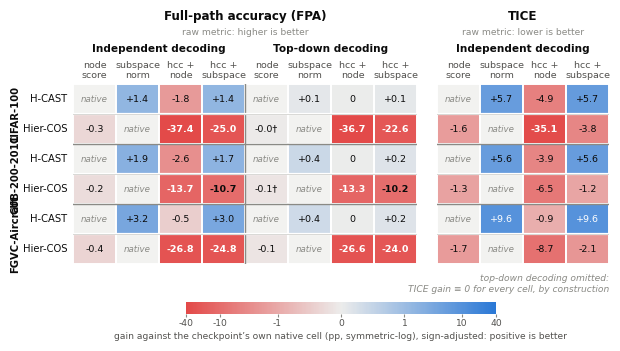

In [7]:
GRID_METRICS = ('fpa', 'tice')          # any subset of posthoc.METRIC_SPECS

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    if SAVE_PLOTS:
        PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    def path(name):
        return (PLOT_OUTPUT_DIR / f'{name}.pdf') if SAVE_PLOTS else None

    posthoc.effect_grid(gain_summary, paired, absolute_summary,
                        metrics=GRID_METRICS, save_path=path('effect_grid'))

## 2. Absolute values corresponding to the relative effects

The grid below has the same rows and inference cells as the relative grid immediately above, but
reports raw test values. Use the pair together: the first shows what changed relative to native
inference, while this one shows the absolute level and the comparison with other models on the same
dataset.

[note] 12 columns need 6.48 in; at width=\textwidth LaTeX scales it to 97%.


**Raw test values of every inference cell**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, Hier-COS · independent and top-down decoding · metrics: FPA, TICE

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/absolute_grid.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/absolute_grid.png


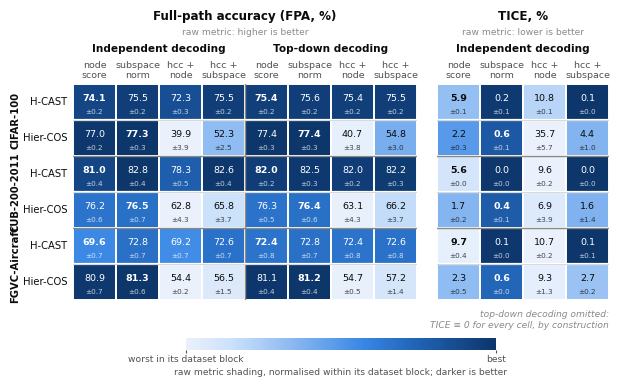

In [8]:
ABS_GRID_METRICS = GRID_METRICS      # any subset of posthoc.METRIC_SPECS
ABS_SHOW_SPREAD = True               # print the sample SD under each mean
# 'dataset' compares every model on the same dataset; 'row' rescales inside each
# model; 'panel' uses one ramp for the entire metric panel.
ABS_SHADE_SCOPE = 'dataset'

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    posthoc.absolute_grid(absolute_summary, metrics=ABS_GRID_METRICS,
                          show_spread=ABS_SHOW_SPREAD, shade_scope=ABS_SHADE_SCOPE,
                          show_footer=False,
                          save_path=path('absolute_grid'))

## 3. Top-down versus independent decoding

With the readout fixed, this section measures what top-down decoding contributes relative to
independent decoding. The quantity is a relative FPA change, formed per seed before aggregation.
Top-down and independent values are read from their corresponding validation-selected checkpoints.

Relative gain of top-down over independent decoding (test FPA; per-seed 100*(td-ind)/ind, mean ± sample SD):


,dataset,model,readout,independent FPA %,independent SD,top-down FPA %,top-down − independent (pp),relative gain %,relative SD,seeds,same sign in every seed,weak_baseline
0,cifar-100,hcast,node_score,74.080,0.193,75.447,1.367,1.845,0.024,3,True,False
1,cifar-100,hiercos,node_score,77.003,0.230,77.390,0.387,0.502,0.146,3,True,False
2,cub-200-2011,hcast,node_score,80.952,0.354,82.022,1.070,1.324,0.669,3,True,False
3,cub-200-2011,hiercos,node_score,76.223,0.584,76.274,0.052,0.069,0.277,3,False,False
4,fgvc-aircraft,hcast,node_score,69.607,0.698,72.417,2.810,4.037,0.356,3,True,False
5,fgvc-aircraft,hiercos,node_score,80.908,0.653,81.108,0.200,0.249,0.254,3,False,False
6,cifar-100,hcast,subspace_norm,75.513,0.194,75.557,0.043,0.057,0.033,3,True,False
7,cifar-100,hiercos,subspace_norm,77.317,0.257,77.410,0.093,0.121,0.019,3,True,False
8,cub-200-2011,hcast,subspace_norm,82.816,0.383,82.453,-0.362,-0.436,0.701,3,True,False
9,cub-200-2011,hiercos,subspace_norm,76.453,0.733,76.407,-0.046,-0.059,0.240,3,False,False


**What top-down decoding buys under the node score readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, Hier-COS · relative FPA change, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/decoder_gain_node_score.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/decoder_gain_node_score.png


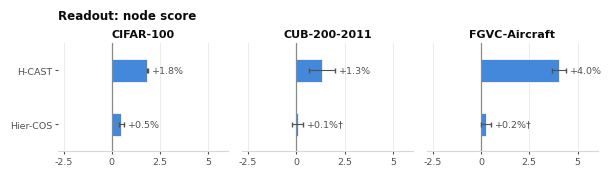

**What top-down decoding buys under the subspace norm readout**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, Hier-COS · relative FPA change, paired per seed

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/decoder_gain_subspace_norm.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/decoder_gain_subspace_norm.png


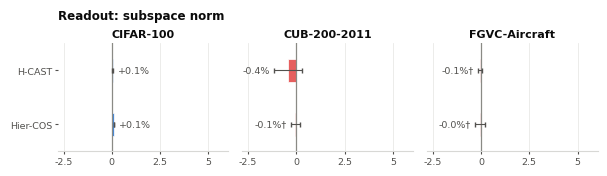

In [9]:
if absolute_summary.empty:
    print('Nothing to compare for the current selection.')
else:
    datasets = [d for d in posthoc.DATASET_ORDER if d in set(view['dataset'])]
    series = posthoc.order_series(set(view['series']))
    decoder_summary = posthoc.relative_decoder_gains(results_long, datasets=datasets,
                                                     series=series)
    if decoder_summary.empty:
        print('No matched independent/top-down rows for the current selection.')
    else:
        print('Relative gain of top-down over independent decoding '
              '(test FPA; per-seed 100*(td-ind)/ind, mean ± sample SD):')
        display(decoder_summary.rename(columns={
            'inference': 'readout', 'series': 'model',
            'independent_fpa': 'independent FPA %', 'independent_std': 'independent SD',
            'topdown_fpa': 'top-down FPA %', 'delta_pp': 'top-down − independent (pp)',
            'relative_gain': 'relative gain %', 'relative_std': 'relative SD',
            'sign_agrees': 'same sign in every seed'}).round(3))

        # One shared x range makes the two readout figures directly comparable.
        shared_xlim = posthoc.relative_gain_limits(decoder_summary)
        for readout in posthoc.READOUT_LABELS:
            posthoc.decoder_gain_figure(decoder_summary, readout, datasets=datasets,
                                        series=series, xlim=shared_xlim,
                                        show_footer=False,
                                        save_path=path(f'decoder_gain_{readout}'))

## 4. Accuracy and consistency under independent decoding

This view complements the decoder comparison: it asks how changing the inference cell moves FPA
and TICE when predictions are decoded independently. Top-down decoding is excluded because its
TICE is identically zero by construction.

**What each inference cell trades: consistency against accuracy**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, Hier-COS · independent decoding

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/accuracy_consistency_map.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/accuracy_consistency_map.png


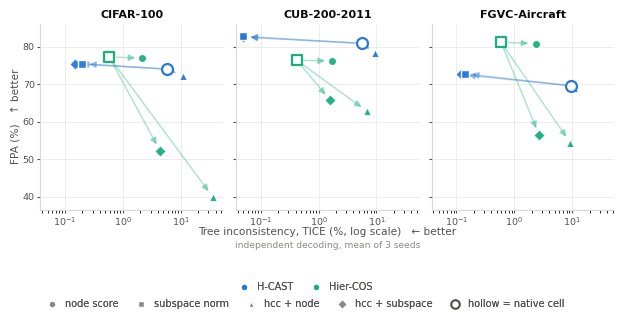

In [10]:
if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    posthoc.accuracy_consistency_map(
        absolute_summary, save_path=path('accuracy_consistency_map'))

## 5. Best inference cell

The chart places every inference cell on one FPA axis per dataset. The table then reports the
winner for the decoder selected by `BEST_CHART_DECODER`; compare the winning margin with the seed
spread before treating a small difference as meaningful.

**Best inference cell across every model (FPA)**  
datasets: CIFAR-100, CUB-200, Aircraft · rows: H-CAST, Hier-COS · independent decoding

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/best_cell_fpa_independent.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/lexmode/best_cell_fpa_independent.png


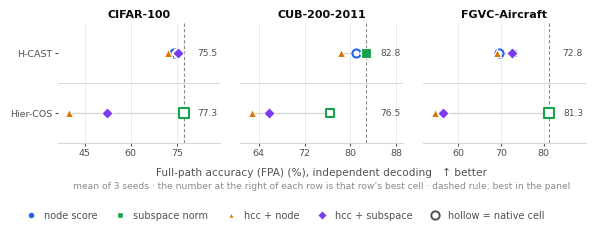

Best cell per (dataset, model), by FPA under independent decoding:


,dataset,model,best_family,best_inference,best_value,best_std,native_inference,native_value,margin,runner_up,runner_up_family,seeds
0,cifar-100,hcast,lexmode,hcc_subspace_norm,75.520000,0.216564,node_score,74.080000,0.006667,subspace_norm,lexmode,3
1,cifar-100,hiercos,lexmode,subspace_norm,77.316667,0.256970,subspace_norm,77.316667,0.313333,node_score,lexmode,3
2,cub-200-2011,hcast,lexmode,subspace_norm,82.815556,0.382958,node_score,80.951559,0.189852,hcc_subspace_norm,lexmode,3
3,cub-200-2011,hiercos,lexmode,subspace_norm,76.452652,0.732518,subspace_norm,76.452652,0.230123,node_score,lexmode,3
4,fgvc-aircraft,hcast,lexmode,subspace_norm,72.837284,0.715893,node_score,69.606961,0.190019,hcc_subspace_norm,lexmode,3
5,fgvc-aircraft,hiercos,lexmode,subspace_norm,81.268127,0.574253,subspace_norm,81.268127,0.360036,node_score,lexmode,3


In [11]:
if absolute_summary.empty:
    print('Nothing to rank for the current selection.')
else:
    posthoc.best_inference_chart(absolute_summary, metric='fpa',
                                 decoder=BEST_CHART_DECODER,
                                 save_path=path(f'best_cell_fpa_{BEST_CHART_DECODER}'))

    print(f'Best cell per (dataset, model), by FPA under '
          f'{posthoc.DECODER_SHORT[BEST_CHART_DECODER]} decoding:')
    display(posthoc.best_cells(absolute_summary, metric='fpa',
                               decoder=BEST_CHART_DECODER))

## Reading the results

Two structural facts are properties of the inference rules, not results, and both have to be held
onto before any tile is interpreted:

- `hcc_node_score` shifts every sibling group by a single constant, so for a signed readout it
  **cannot change any top-down metric** — expect exactly zero gain there for H-CAST, HT-CapsNet and
  HRN, and read only the independent-decoding row. It does move both decoders for Hier-COS, whose
  readout takes the coordinate's magnitude.
- `subspace_norm` squares its inputs, so it discards the sign of whatever it aggregates. In the
  default `probability` space that is harmless — the aggregated values are already non-negative
  evidence, and a confidently rejected class contributes ~0. In the `coordinate` space the sign is
  genuinely lost, which **inverts** the evidence for a sigmoid/BCE head such as HRN's levels 0-1,
  because BCE drives non-target logits to large negative values. Two further properties are worth
  holding onto in either space: a node's own subspace grows with its descendant count, so the coarse
  score carries a `sqrt(fanout)` bias, while a **leaf's** subspace is exactly
  `{coarse parent, mid parent, self}` and so injects ancestor evidence with no fanout term at all.

What this notebook can and cannot support:

- It **can** say whether a post-hoc readout beats what these checkpoints already do, per dataset,
  decoder and seed, because that comparison is within-checkpoint.
- It **cannot** say whether this mechanism beats another one. Every gain here is measured against a
  different zero point per mechanism, so two notebooks' numbers are not on a common scale. Use
  [`all_mechanics.ipynb`](all_mechanics.ipynb) for that, and read the caveat it prints.
- If gains vary strongly by dataset, decoder or seed, report the dependence instead of claiming a
  general mechanism.